In [1]:
print('Hello, World!')

Hello, World!


In [2]:
from sklearn.datasets import fetch_california_housing

californis=fetch_california_housing(as_frame=True)
df=californis.frame

print(df.head())

   MedInc  HouseAge  AveRooms  ...  Latitude  Longitude  MedHouseVal
0  8.3252      41.0  6.984127  ...     37.88    -122.23        4.526
1  8.3014      21.0  6.238137  ...     37.86    -122.22        3.585
2  7.2574      52.0  8.288136  ...     37.85    -122.24        3.521
3  5.6431      52.0  5.817352  ...     37.85    -122.25        3.413
4  3.8462      52.0  6.281853  ...     37.85    -122.25        3.422

[5 rows x 9 columns]


EDA 

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Correlation Matrix

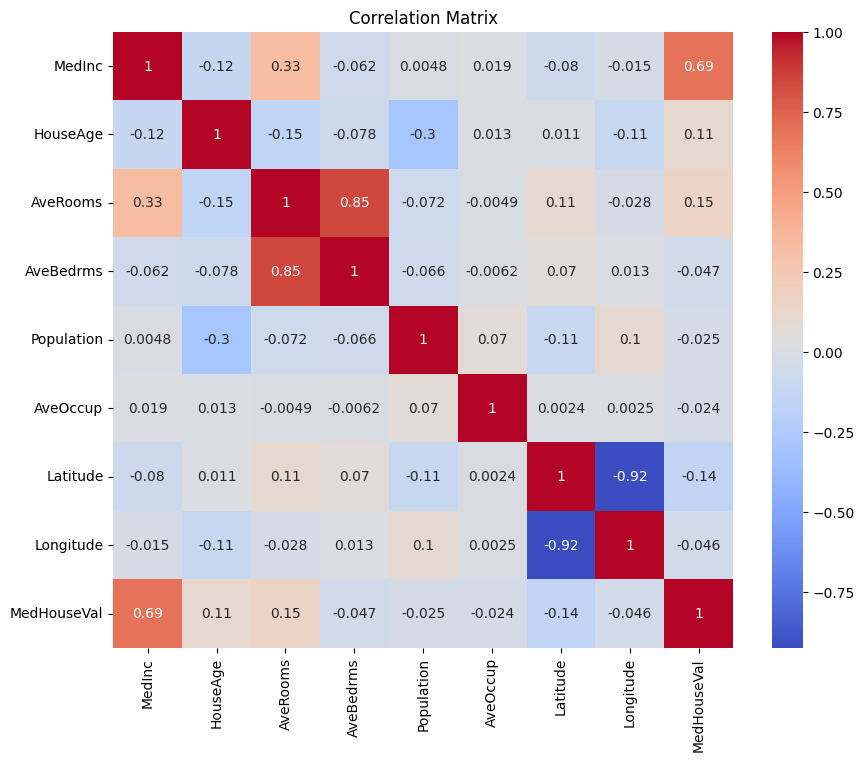

In [8]:
corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

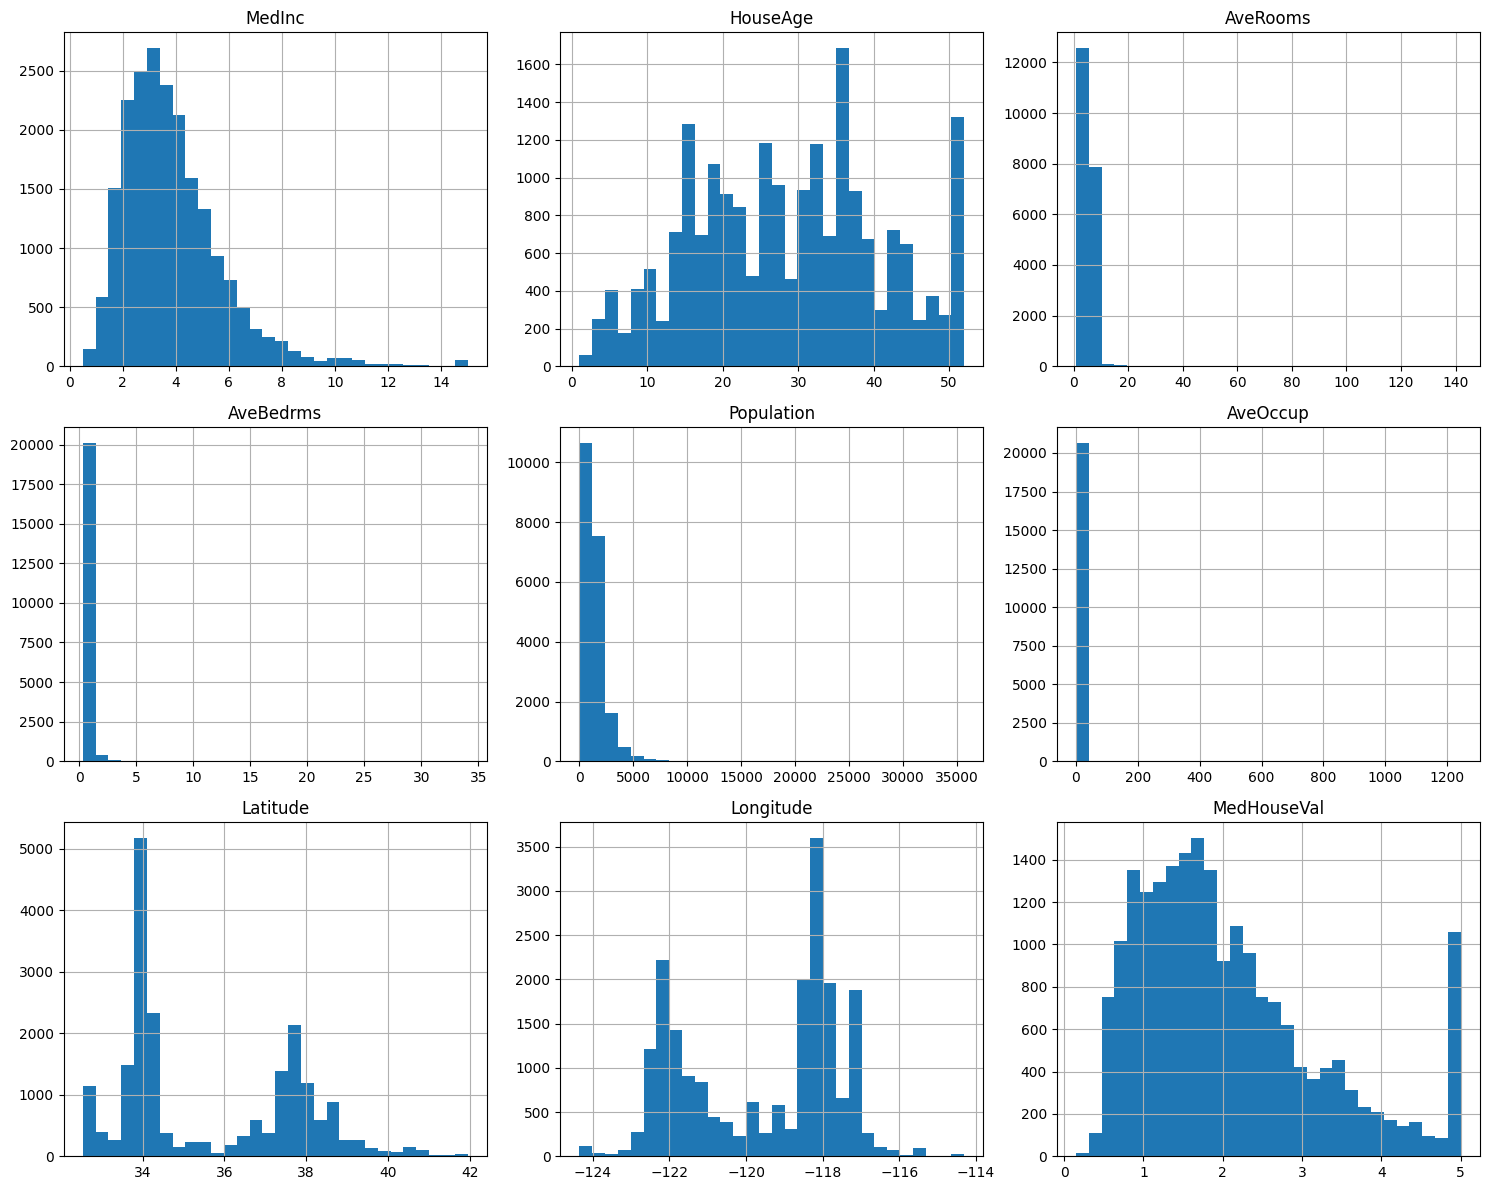

In [9]:
df.hist(figsize=(15,12), bins=30)
plt.tight_layout()
plt.show()

Normalize using MinMaxScaler

In [10]:
from sklearn.preprocessing import  MinMaxScaler

In [11]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[0.53966842 0.78431373 0.0435123  0.02046866 0.00894083 0.00149943
  0.5674814  0.21115538]
 [0.53802706 0.39215686 0.03822395 0.01892926 0.0672104  0.00114074
  0.565356   0.21215139]
 [0.46602805 1.         0.05275646 0.02194011 0.01381765 0.00169796
  0.5642933  0.21015936]
 [0.35469856 1.         0.03524099 0.02192864 0.01555537 0.0014933
  0.5642933  0.20916335]
 [0.23077613 1.         0.03853386 0.02216644 0.01575156 0.00119838
  0.5642933  0.20916335]]


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [13]:
test_sizes = [0.1, 0.3, 0.4]

for size in test_sizes:

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled,
        y,
        test_size=size,
        random_state=42
    )

    model = LinearRegression()

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    score = r2_score(y_test, y_pred)

    print(f"Test Size = {size} --> R2 Score = {score:.4f}")

Test Size = 0.1 --> R2 Score = 0.5808
Test Size = 0.3 --> R2 Score = 0.5958
Test Size = 0.4 --> R2 Score = 0.5939


In [14]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

In [15]:
kf5 = KFold(n_splits=5, shuffle=True, random_state=42)

scores5 = cross_val_score(
    LinearRegression(),
    X_scaled,
    y,
    cv=kf5,
    scoring="r2"
)

print("5-Fold Scores")
print(scores5)

print("Average:", scores5.mean())

5-Fold Scores
[0.57578771 0.61374822 0.60856043 0.62126494 0.5875292 ]
Average: 0.6013781013684619


In [16]:
kf10 = KFold(n_splits=10, shuffle=True, random_state=42)

scores10 = cross_val_score(
    LinearRegression(),
    X_scaled,
    y,
    cv=kf10,
    scoring="r2"
)

print("10-Fold Scores")
print(scores10)

print("Average:", scores10.mean())

10-Fold Scores
[0.58083533 0.57017917 0.6343602  0.5945333  0.6156131  0.60268638
 0.59072937 0.63988315 0.57780603 0.5941262 ]
Average: 0.6000752228653949
